In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Evaluacija modela

Nakon treniranja modela potrebno je provjeriti koliko su oni zapravo uspješni. Samo visoka točnost nije uvijek dovoljna pa je korisno detaljnije analizirati rezultate.

U ovom dijelu projekta uspoređuju se rezultati Random Forest i SVM modela te se promatra gdje modeli griješe i koje značajke imaju najveći utjecaj na klasifikaciju.


In [2]:
data = pd.read_csv(
    "feature_matrix.csv"
)

data.head()

,length,net_charge,hydrophobicity,molecular_weight,aromaticity,isoelectric_point,A,C,D,E,...,N,P,Q,R,S,T,V,W,Y,label
0,12,4,-1.458333,1591.8412,0.166667,11.712568,8.333333,8.333333,0.0,0.0,...,8.333333,0.0,16.666667,25.000000,0.000000,0.000000,8.333333,8.333333,0.0,1
1,25,-1,-0.412000,3184.4944,0.360000,6.260497,4.000000,0.000000,4.0,4.0,...,0.000000,8.0,0.000000,4.000000,8.000000,8.000000,0.000000,4.000000,12.0,0
2,17,1,0.605882,1859.2016,0.058824,8.239656,11.764706,5.882353,0.0,0.0,...,11.764706,0.0,0.000000,0.000000,0.000000,0.000000,5.882353,5.882353,0.0,1
3,12,4,0.691667,1536.9117,0.083333,11.999968,8.333333,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,33.333333,0.000000,0.000000,25.000000,8.333333,0.0,1
4,12,1,1.816667,1240.5746,0.000000,8.750052,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,8.333333,8.333333,0.000000,0.000000,0.0,1


In [3]:
X = data.drop(
    columns=["label"]
)

y = data["label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [7]:
svm = SVC(
    kernel="rbf",
    probability=True
)

svm.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm.predict(
    X_test_scaled
)

## Matrice zabune

Matrica zabune prikazuje koliko je primjera model ispravno klasificirao, a koliko ih je svrstao u pogrešnu klasu.

Na temelju ovih rezultata može se vidjeti razlikuje li model uspješno antimikrobne peptide od neantimikrobnih te u kojim situacijama najčešće dolazi do pogreške.


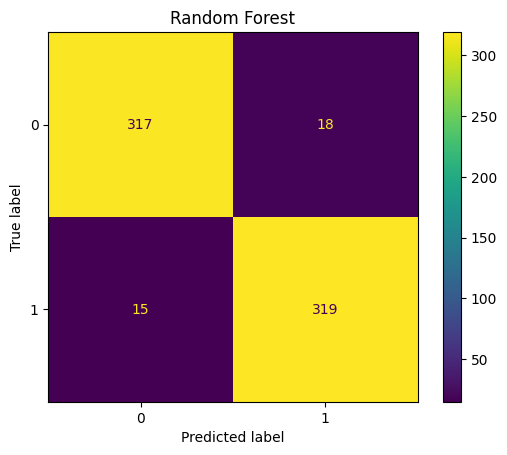

In [8]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title(
    "Random Forest"
)

plt.show()

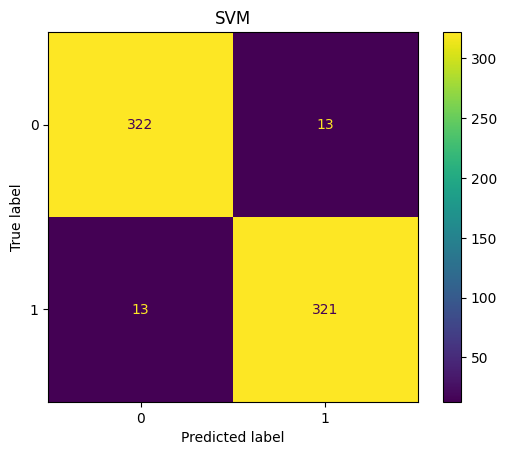

In [9]:
cm_svm = confusion_matrix(
    y_test,
    svm_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm
)

disp.plot()

plt.title(
    "SVM"
)

plt.show()

In [10]:
feature_importance = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": rf.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
5,isoelectric_point,0.204269
1,net_charge,0.142277
16,M,0.092887
14,K,0.065549
12,H,0.039847
2,hydrophobicity,0.039367
8,D,0.037713
15,L,0.037019
9,E,0.030995
4,aromaticity,0.027210


## Analiza rezultata

Osim same točnosti, zanimljivo je vidjeti koje značajke najviše utječu na odluku modela. Na taj način možemo bolje razumjeti što model smatra važnim prilikom klasifikacije peptida.

Prikazana je i ROC krivulja koja daje dodatni uvid u kvalitetu modela. Što je krivulja bliže gornjem lijevom kutu, model bolje razlikuje dvije klase.


In [14]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Tablica spremljena.")

Tablica spremljena.


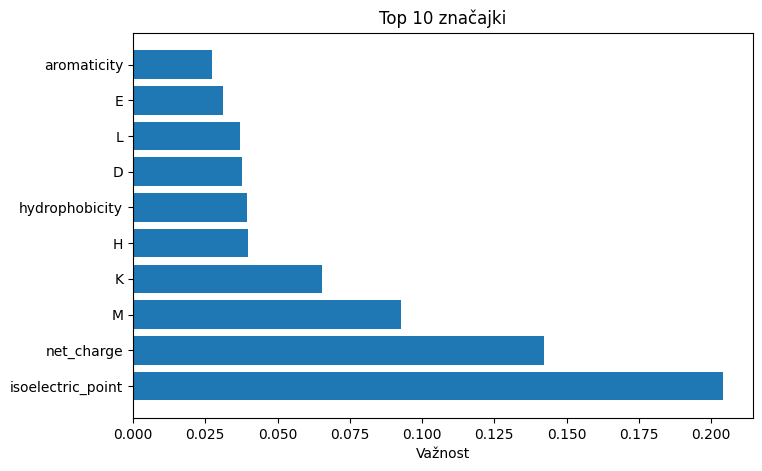

In [11]:
top_features = feature_importance.head(10)

plt.figure(
    figsize=(8,5)
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "Top 10 značajki"
)

plt.xlabel(
    "Važnost"
)

plt.show()

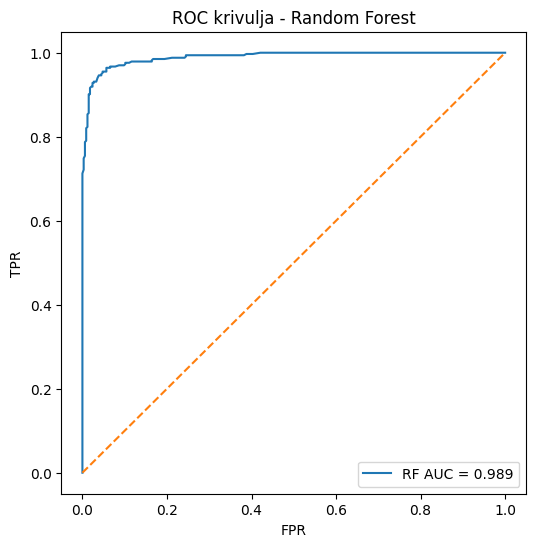

In [12]:
rf_prob = rf.predict_proba(
    X_test
)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"RF AUC = {roc_auc_rf:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title(
    "ROC krivulja - Random Forest"
)

plt.legend()

plt.show()

## Pogrešno klasificirani primjeri

Nijedan model nije savršen pa je korisno pogledati primjere koje model nije ispravno klasificirao.

Analizom takvih primjera može se bolje razumjeti gdje model ima poteškoća te koje bi se stvari mogle poboljšati u budućim verzijama projekta.


In [13]:
results = X_test.copy()

results["true_label"] = y_test.values

results["predicted_label"] = rf_pred

wrong_predictions = results[
    results["true_label"]
    !=
    results["predicted_label"]
]

print(
    "Pogrešno klasificirani peptidi:",
    len(wrong_predictions)
)

wrong_predictions.head()

Pogrešno klasificirani peptidi: 33


,length,net_charge,hydrophobicity,molecular_weight,aromaticity,isoelectric_point,A,C,D,E,...,P,Q,R,S,T,V,W,Y,true_label,predicted_label
196,7,0,0.371429,984.1122,0.428571,7.022423,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0
1068,7,1,0.542857,838.0077,0.142857,8.728197,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,28.571429,14.285714,0.000000,0,1
2006,15,-2,-0.053333,1749.0184,0.000000,4.316717,13.333333,0.0,13.333333,13.333333,...,0.000000,0.000000,13.333333,6.666667,0.000000,6.666667,0.000000,0.000000,1,0
1737,15,2,-1.526667,1790.0953,0.000000,9.528572,6.666667,0.0,6.666667,6.666667,...,6.666667,6.666667,0.000000,6.666667,0.000000,0.000000,0.000000,0.000000,1,0
1333,15,-1,-0.380000,1707.8370,0.133333,4.050028,0.000000,0.0,6.666667,0.000000,...,0.000000,13.333333,0.000000,6.666667,6.666667,6.666667,6.666667,6.666667,1,0


In [15]:
wrong_predictions.to_csv(
    "wrong_predictions.csv",
    index=False
)

In [17]:
from sklearn.metrics import accuracy_score
results_table = pd.DataFrame(
    {
        "Model": [
            "Random Forest",
            "SVM"
        ],
        "Accuracy": [
            accuracy_score(y_test, rf_pred),
            accuracy_score(y_test, svm_pred)
        ]
    }
)

results_table

,Model,Accuracy
0,Random Forest,0.950673
1,SVM,0.961136


In [18]:
results_table.to_csv(
    "model_results.csv",
    index=False
)

## Zaključak

Dobiveni rezultati pokazuju da je moguće uspješno razlikovati antimikrobne i neantimikrobne peptide pomoću značajki izračunatih iz njihovih sekvenci.

Oba modela ostvarila su vrlo dobre rezultate, pri čemu je SVM postigao nešto veću točnost od Random Forest modela. Najveći doprinos klasifikaciji dale su značajke povezane sa sastavom aminokiselina i osnovnim svojstvima peptida.

Na temelju dobivenih rezultata može se zaključiti da odabrani pristup daje dobre rezultate i predstavlja dobru osnovu za daljnja istraživanja antimikrobnih peptida.
